# CycleGAN training cepat: Photo ↔ Monet (256px)

Notebook ini melanjutkan training CycleGAN 256×256 dengan checkpoint yang sudah ada, lalu menyimpan hasilnya secara terpisah di `checkpoints/cyclegan_v2_fast/`. Optimasi memakai mixed precision, pemuatan data paralel yang diukur otomatis, serta menghindari gradien discriminator yang tidak dipakai saat update generator. Arsitektur, batch size, dan jumlah update per epoch tetap sama.

Training penuh tidak dijalankan otomatis. Jalankan cell dari atas; cell training akan melanjutkan checkpoint lama bila tersedia.

In [1]:
import random
import sys
import shutil
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

EPOCHS = 10                 # Target total epoch; aman dilanjutkan dari checkpoint
RUN_BENCHMARK = True        # Set False setelah benchmark pertama saat melanjutkan training
BATCH_SIZE = 1
LAMBDA_CYCLE = 10.0
LAMBDA_IDENTITY = 5.0       # 0.5 * LAMBDA_CYCLE

Device: cuda
GPU: NVIDIA GeForce RTX 4060


/mnt/media/Projects/Personal/App/GAN_Art/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Simpan checkpoint di Google Drive (Colab)

File di `/content` ada di VM sementara Colab dan bisa hilang saat runtime dihapus. Cell berikut memasang Drive; beri otorisasi saat diminta. Hanya checkpoint dan gambar evaluasi yang disimpan di Drive, dataset tetap dibaca dari disk runtime.

In [2]:
try:
    from google.colab import drive
    IN_COLAB = True
    drive.mount("/content/drive")
    CHECKPOINT_ROOT = Path("/content/drive/MyDrive/GAN_Art/checkpoints/cyclegan_v2_fast")
    SOURCE_CHECKPOINTS = [
        Path("/content/drive/MyDrive/GAN_Art/checkpoints/cyclegan_v2/latest.pt"),
        Path("/content/checkpoints/cyclegan_v2/latest.pt"),
    ]
except ModuleNotFoundError:
    IN_COLAB = False
    CHECKPOINT_ROOT = None
    SOURCE_CHECKPOINTS = []

## Data dan split validasi

10% gambar tiap domain ditahan untuk validasi. Foto dan Monet tidak dipasangkan; keduanya hanya perlu berasal dari domain yang tepat. Resize menjaga rasio aspek, lalu crop menghasilkan input 256×256. Validasi memakai center crop yang deterministik.

In [3]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebook" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))
DATASET_PATH = PROJECT_ROOT / "dataset" / "gan-getting-started"
CHECKPOINT_DIR = CHECKPOINT_ROOT if IN_COLAB else PROJECT_ROOT / "checkpoints" / "cyclegan_v2_fast"
if not IN_COLAB:
    SOURCE_CHECKPOINTS = [PROJECT_ROOT / "checkpoints" / "cyclegan_v2" / "latest.pt"]
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_PATH = CHECKPOINT_DIR / "latest.pt"
if not CHECKPOINT_PATH.exists():
    for source_checkpoint in SOURCE_CHECKPOINTS:
        if source_checkpoint.exists():
            shutil.copy2(source_checkpoint, CHECKPOINT_PATH)
            print("Checkpoint awal disalin:", source_checkpoint, "→", CHECKPOINT_PATH)
            break
SAMPLE_DIR = CHECKPOINT_DIR / "samples"

MONET_FILES = sorted((DATASET_PATH / "monet_jpg").glob("*.jpg"))
PHOTO_FILES = sorted((DATASET_PATH / "photo_jpg").glob("*.jpg"))
if not MONET_FILES or not PHOTO_FILES:
    raise FileNotFoundError(f"Dataset tidak ditemukan atau kosong: {DATASET_PATH}")

def split_files(files, val_fraction=0.1):
    files = list(files)
    random.Random(SEED).shuffle(files)
    n_val = max(1, round(len(files) * val_fraction))
    return files[n_val:], files[:n_val]

monet_train_files, monet_val_files = split_files(MONET_FILES)
photo_train_files, photo_val_files = split_files(PHOTO_FILES)

train_transform = transforms.Compose([
    transforms.Resize(286, interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.RandomCrop(256),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5,) * 3, (0.5,) * 3),
])
val_transform = transforms.Compose([
    transforms.Resize(286, interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.CenterCrop(256),
    transforms.ToTensor(),
    transforms.Normalize((0.5,) * 3, (0.5,) * 3),
])

class ImageDataset(Dataset):
    def __init__(self, filenames, transform):
        self.filenames = filenames
        self.transform = transform

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, index):
        with Image.open(self.filenames[index]) as image:
            return self.transform(image.convert("RGB"))

monet_train_ds = ImageDataset(monet_train_files, train_transform)
photo_train_ds = ImageDataset(photo_train_files, train_transform)
monet_val_ds = ImageDataset(monet_val_files, val_transform)
photo_val_ds = ImageDataset(photo_val_files, val_transform)

def make_train_loader(dataset, workers):
    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=workers,
        pin_memory=device.type == "cuda",
        persistent_workers=workers > 0,
    )

def benchmark_num_workers(warmup_batches=10, sample_batches=64):
    timings = {}
    for workers in (0, 2, 4):
        photo_iter = iter(make_train_loader(photo_train_ds, workers))
        monet_iter = iter(make_train_loader(monet_train_ds, workers))
        for _ in range(warmup_batches):
            next(photo_iter)
            next(monet_iter)
        started = perf_counter()
        for _ in range(sample_batches):
            next(photo_iter)
            next(monet_iter)
        timings[workers] = (perf_counter() - started) / sample_batches
        del photo_iter, monet_iter
    selected = min(timings, key=timings.get)
    print("Data loader seconds/pair:", {k: round(v, 4) for k, v in timings.items()})
    print("Selected num_workers:", selected)
    return selected

NUM_WORKERS = benchmark_num_workers()
photo_loader = make_train_loader(photo_train_ds, NUM_WORKERS)
monet_loader = make_train_loader(monet_train_ds, NUM_WORKERS)
print(f"Train: {len(photo_train_ds)} photo, {len(monet_train_ds)} Monet")
print(f"Validasi: {len(photo_val_ds)} photo, {len(monet_val_ds)} Monet")
print("Checkpoint dir:", CHECKPOINT_DIR)

Data loader seconds/pair: {0: 0.0045, 2: 0.0018, 4: 0.0022}
Selected num_workers: 2
Train: 6334 photo, 270 Monet
Validasi: 704 photo, 30 Monet
Checkpoint dir: /mnt/media/Projects/Personal/App/GAN_Art/checkpoints/cyclegan_v2_fast


## Model

Generator memakai dua tahap downsampling, residual blocks, dan upsampling. Discriminator menilai patch lokal gambar (PatchGAN).

In [4]:
from gan_art.models import Discriminator, Generator

In [5]:
USE_AMP = device.type == "cuda"
AMP_DTYPE = (
    torch.bfloat16 if USE_AMP and torch.cuda.is_bf16_supported()
    else torch.float16
)
USE_GRAD_SCALER = USE_AMP and AMP_DTYPE == torch.float16
USE_CHANNELS_LAST = False  # Aktifkan hanya jika benchmark pada GPU ini lebih cepat
MEMORY_FORMAT = torch.channels_last if USE_CHANNELS_LAST else torch.contiguous_format

photo_to_monet = Generator().to(device, memory_format=MEMORY_FORMAT)
monet_to_photo = Generator().to(device, memory_format=MEMORY_FORMAT)
monet_discriminator = Discriminator().to(device, memory_format=MEMORY_FORMAT)
photo_discriminator = Discriminator().to(device, memory_format=MEMORY_FORMAT)

criterion_gan = nn.MSELoss()  # Least-squares GAN objective
criterion_l1 = nn.L1Loss()
optimizer_G = torch.optim.Adam(
    list(photo_to_monet.parameters()) + list(monet_to_photo.parameters()),
    lr=2e-4, betas=(0.5, 0.999),
)
optimizer_D = torch.optim.Adam(
    list(monet_discriminator.parameters()) + list(photo_discriminator.parameters()),
    lr=2e-4, betas=(0.5, 0.999),
)
scaler = torch.amp.GradScaler("cuda", enabled=USE_GRAD_SCALER)
print("AMP:", AMP_DTYPE if USE_AMP else "off", "| GradScaler:", USE_GRAD_SCALER)

AMP: torch.bfloat16 | GradScaler: False


## Evaluasi tetap

Gunakan gambar validasi yang sama setiap kali membandingkan checkpoint. Grid menampilkan input, hasil terjemahan, lalu hasil terjemahan balik. Nilai `cycle L1` mengukur seberapa dekat rekonstruksi ke input setelah dua arah terjemahan; nilainya membantu memantau konsistensi, tetapi **bukan skor kualitas gaya**.

In [6]:
@torch.inference_mode()
def evaluate(n=4, save_path=None, show=True):
    n = min(n, len(photo_val_ds), len(monet_val_ds))
    if n < 1:
        raise ValueError("Validasi memerlukan minimal satu gambar di tiap domain")

    models = (photo_to_monet, monet_to_photo)
    was_training = [model.training for model in models]
    for model in models:
        model.eval()

    photo_cycle_errors, monet_cycle_errors = [], []
    fig, axes = plt.subplots(6, n, figsize=(3 * n, 15), squeeze=False)
    row_titles = [
        "Photo input", "Photo → Monet", "Rekonstruksi photo",
        "Monet input", "Monet → photo", "Rekonstruksi Monet",
    ]
    for row, title in enumerate(row_titles):
        axes[row, 0].set_ylabel(title, fontsize=10)

    for i in range(n):
        photo = photo_val_ds[i].unsqueeze(0).to(device)
        monet = monet_val_ds[i].unsqueeze(0).to(device)
        fake_monet = photo_to_monet(photo)
        rec_photo = monet_to_photo(fake_monet)
        fake_photo = monet_to_photo(monet)
        rec_monet = photo_to_monet(fake_photo)
        photo_cycle_errors.append(F.l1_loss(rec_photo, photo).item())
        monet_cycle_errors.append(F.l1_loss(rec_monet, monet).item())

        images = (photo, fake_monet, rec_photo, monet, fake_photo, rec_monet)
        for row, image in enumerate(images):
            pixels = ((image[0].cpu().clamp(-1, 1) + 1) / 2).permute(1, 2, 0).numpy()
            axes[row, i].imshow(pixels)
            axes[row, i].axis("off")
            if i == 0:
                axes[row, i].set_title(row_titles[row], loc="left", fontsize=9)

    metrics = {
        "photo_cycle_l1": float(np.mean(photo_cycle_errors)),
        "monet_cycle_l1": float(np.mean(monet_cycle_errors)),
    }
    fig.suptitle(
        f"Validation | Photo cycle L1: {metrics['photo_cycle_l1']:.4f} | "
        f"Monet cycle L1: {metrics['monet_cycle_l1']:.4f}"
    )
    fig.tight_layout()
    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=130, bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close(fig)

    for model, training in zip(models, was_training):
        model.train(training)
    return metrics


## Training dan checkpoint

Checkpoint baru disimpan di `checkpoints/cyclegan_v2_fast/` (atau folder `cyclegan_v2_fast` di Google Drive). Jika belum ada, notebook menyalin `latest.pt` dari training lama dan melanjutkan dari sana. Notebook lama dan checkpoint sumber tidak ditimpa.

Training melaporkan durasi dan detik per update setiap epoch. `num_workers` dipilih dari pengukuran 0, 2, dan 4 di cell data. `USE_CHANNELS_LAST` tetap nonaktif kecuali pengukuran pada GPU Anda membuktikan peningkatan. Validasi tetap memakai grid yang sama; cycle L1 membantu memantau konsistensi, bukan kualitas gaya.

In [7]:
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
SAMPLE_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_PATH = CHECKPOINT_DIR / "latest.pt"


def save_checkpoint(epoch, history):
    state = {
        "epoch": epoch,
        "photo_to_monet": photo_to_monet.state_dict(),
        "monet_to_photo": monet_to_photo.state_dict(),
        "monet_discriminator": monet_discriminator.state_dict(),
        "photo_discriminator": photo_discriminator.state_dict(),
        "optimizer_G": optimizer_G.state_dict(),
        "optimizer_D": optimizer_D.state_dict(),
        "scaler": scaler.state_dict() if USE_GRAD_SCALER else None,
        "history": history,
    }
    temporary_path = CHECKPOINT_PATH.with_suffix(".tmp")
    torch.save(state, temporary_path)
    temporary_path.replace(CHECKPOINT_PATH)


def load_checkpoint(path=CHECKPOINT_PATH):
    global scaler
    state = torch.load(path, map_location=device, weights_only=False)
    photo_to_monet.load_state_dict(state["photo_to_monet"])
    monet_to_photo.load_state_dict(state["monet_to_photo"])
    monet_discriminator.load_state_dict(state["monet_discriminator"])
    photo_discriminator.load_state_dict(state["photo_discriminator"])
    optimizer_G.load_state_dict(state["optimizer_G"])
    optimizer_D.load_state_dict(state["optimizer_D"])
    if USE_GRAD_SCALER:
        if state.get("scaler"):
            scaler.load_state_dict(state["scaler"])
        else:
            scaler = torch.amp.GradScaler("cuda", enabled=True)
    return state["epoch"], state["history"]


def load_generators_for_inference(path=CHECKPOINT_PATH):
    state = torch.load(path, map_location=device, weights_only=False)
    photo_to_monet.load_state_dict(state["photo_to_monet"])
    monet_to_photo.load_state_dict(state["monet_to_photo"])
    photo_to_monet.eval()
    monet_to_photo.eval()
    return state["epoch"]


def repeat_loader(loader):
    while True:
        yield from loader


def amp_context(enabled):
    if not enabled:
        from contextlib import nullcontext
        return nullcontext()
    return torch.autocast(device_type="cuda", dtype=AMP_DTYPE)


def train_step(real_photo, real_monet, use_amp=USE_AMP, memory_format=MEMORY_FORMAT):
    non_blocking = device.type == "cuda"
    real_photo = real_photo.to(device, non_blocking=non_blocking, memory_format=memory_format)
    real_monet = real_monet.to(device, non_blocking=non_blocking, memory_format=memory_format)

    optimizer_G.zero_grad(set_to_none=True)
    optimizer_D.zero_grad(set_to_none=True)
    for discriminator in (monet_discriminator, photo_discriminator):
        discriminator.requires_grad_(False)
    with amp_context(use_amp):
        fake_monet = photo_to_monet(real_photo)
        fake_photo = monet_to_photo(real_monet)
        pred_fake_monet_for_g = monet_discriminator(fake_monet)
        pred_fake_photo_for_g = photo_discriminator(fake_photo)
        loss_adv = (
            criterion_gan(pred_fake_monet_for_g, torch.ones_like(pred_fake_monet_for_g))
            + criterion_gan(pred_fake_photo_for_g, torch.ones_like(pred_fake_photo_for_g))
        )
        rec_photo = monet_to_photo(fake_monet)
        rec_monet = photo_to_monet(fake_photo)
        loss_cycle = criterion_l1(rec_photo, real_photo) + criterion_l1(rec_monet, real_monet)
        identity_monet = photo_to_monet(real_monet)
        identity_photo = monet_to_photo(real_photo)
        loss_identity = criterion_l1(identity_monet, real_monet) + criterion_l1(identity_photo, real_photo)
        loss_G = loss_adv + LAMBDA_CYCLE * loss_cycle + LAMBDA_IDENTITY * loss_identity
    if use_amp:
        scaler.scale(loss_G).backward()
        scaler.step(optimizer_G)
    else:
        loss_G.backward()
        optimizer_G.step()
    for discriminator in (monet_discriminator, photo_discriminator):
        discriminator.requires_grad_(True)

    with amp_context(use_amp):
        pred_real_monet = monet_discriminator(real_monet)
        pred_fake_monet = monet_discriminator(fake_monet.detach())
        loss_D_monet = (
            criterion_gan(pred_real_monet, torch.ones_like(pred_real_monet))
            + criterion_gan(pred_fake_monet, torch.zeros_like(pred_fake_monet))
        )
        pred_real_photo = photo_discriminator(real_photo)
        pred_fake_photo = photo_discriminator(fake_photo.detach())
        loss_D_photo = (
            criterion_gan(pred_real_photo, torch.ones_like(pred_real_photo))
            + criterion_gan(pred_fake_photo, torch.zeros_like(pred_fake_photo))
        )
        loss_D = loss_D_monet + loss_D_photo
    if use_amp:
        scaler.scale(loss_D).backward()
        scaler.step(optimizer_D)
        scaler.update()
    else:
        loss_D.backward()
        optimizer_D.step()
    return loss_G.detach(), loss_D.detach(), loss_cycle.detach(), loss_identity.detach()


def benchmark_training(steps=100, warmup=10):
    global USE_CHANNELS_LAST, MEMORY_FORMAT
    if device.type != "cuda":
        print("Benchmark FP32/AMP dilewati: CUDA tidak tersedia.")
        return {}
    if not CHECKPOINT_PATH.exists():
        print("Benchmark dilewati: checkpoint awal tidak ditemukan.")
        return {}

    fixed_batches = []
    photo_iter, monet_iter = iter(photo_loader), iter(monet_loader)
    for _ in range(steps + warmup):
        fixed_batches.append((next(photo_iter), next(monet_iter)))

    contiguous = torch.contiguous_format
    scenarios = [("FP32", False, contiguous), ("AMP", True, contiguous)]
    if USE_AMP:
        scenarios.append(("AMP + channels_last", True, torch.channels_last))

    results = {}
    for name, use_amp, memory_format in scenarios:
        load_checkpoint(CHECKPOINT_PATH)
        for model in (photo_to_monet, monet_to_photo, monet_discriminator, photo_discriminator):
            model.to(memory_format=memory_format)
        last_losses = None
        started = None
        torch.cuda.synchronize()
        for index, (photo_batch, monet_batch) in enumerate(fixed_batches):
            last_losses = train_step(photo_batch, monet_batch, use_amp, memory_format)
            if index + 1 == warmup:
                torch.cuda.synchronize()
                started = perf_counter()
        torch.cuda.synchronize()
        elapsed = perf_counter() - started
        last_losses = torch.stack(last_losses).cpu()
        if not torch.isfinite(last_losses).all():
            raise FloatingPointError(f"Loss tidak finite pada benchmark {name}: {last_losses.tolist()}")
        results[name] = elapsed / steps
        print(f"{name}: {results[name]:.4f} sec/update")

    amp_seconds = results["AMP"]
    speedup = results["FP32"] / amp_seconds
    use_channels_last = results.get("AMP + channels_last", float("inf")) <= amp_seconds * 0.95
    USE_CHANNELS_LAST = use_channels_last
    MEMORY_FORMAT = torch.channels_last if use_channels_last else torch.contiguous_format
    load_checkpoint(CHECKPOINT_PATH)
    for model in (photo_to_monet, monet_to_photo, monet_discriminator, photo_discriminator):
        model.to(memory_format=MEMORY_FORMAT)
    print(f"AMP speedup vs FP32: {speedup:.2f}x (target awal: 2x)")
    print("channels_last:", "aktif" if USE_CHANNELS_LAST else "nonaktif; tidak cukup cepat")
    return results


def train(epochs, start_epoch=0, history=None):
    history = list(history or [])
    steps_per_epoch = max(len(photo_loader), len(monet_loader))
    photo_batches = iter(repeat_loader(photo_loader))
    monet_batches = iter(repeat_loader(monet_loader))

    epoch_bar = tqdm(range(start_epoch, epochs), desc="Training", unit="epoch")
    for epoch in epoch_bar:
        epoch_started = perf_counter()
        totals = torch.zeros(4, device=device)
        batch_bar = tqdm(
            range(steps_per_epoch),
            desc=f"Epoch {epoch + 1}/{epochs}",
            unit="batch",
            leave=False,
        )
        for step in batch_bar:
            losses = train_step(next(photo_batches), next(monet_batches))
            totals += torch.stack(losses)
            if (step + 1) % 100 == 0 or step + 1 == steps_per_epoch:
                loss_G, loss_D, loss_cycle, _ = losses
                batch_bar.set_postfix(
                    G=f"{loss_G.item():.3f}",
                    D=f"{loss_D.item():.3f}",
                    cycle=f"{loss_cycle.item():.3f}",
                )

        mean_G, mean_D, mean_cycle, mean_identity = (totals / steps_per_epoch).cpu().tolist()
        metrics = evaluate(n=4, save_path=SAMPLE_DIR / f"epoch_{epoch + 1:03d}.png", show=False)
        history.append({
            "epoch": epoch + 1,
            "loss_G": mean_G,
            "loss_D": mean_D,
            "loss_cycle": mean_cycle,
            "loss_identity": mean_identity,
            **metrics,
        })
        save_checkpoint(epoch + 1, history)
        elapsed = perf_counter() - epoch_started
        epoch_bar.set_postfix(
            stage="epoch complete",
            G=f"{mean_G:.3f}",
            D=f"{mean_D:.3f}",
            seconds_per_step=f"{elapsed / steps_per_epoch:.3f}",
        )
        print(
            f"Epoch [{epoch + 1}/{epochs}] "
            f"G: {mean_G:.4f} | D: {mean_D:.4f} | "
            f"cycle: {mean_cycle:.4f} | identity: {mean_identity:.4f} | "
            f"val cycle L1 photo/Monet: {metrics['photo_cycle_l1']:.4f}/"
            f"{metrics['monet_cycle_l1']:.4f} | "
            f"elapsed: {elapsed / 60:.1f} min ({elapsed / steps_per_epoch:.3f} sec/update)"
        )
    return history

In [8]:
BENCHMARK_RESULTS = benchmark_training(steps=100, warmup=10) if RUN_BENCHMARK and device.type == "cuda" else {}
RESUME = True
START_EPOCH, history = 0, []
if RESUME and CHECKPOINT_PATH.exists():
    START_EPOCH, history = load_checkpoint()
    print(f"Melanjutkan dari epoch {START_EPOCH}")

history = train(EPOCHS, start_epoch=START_EPOCH, history=history)

FP32: 0.2986 sec/update
AMP: 0.1715 sec/update
AMP + channels_last: 0.1899 sec/update
AMP speedup vs FP32: 1.74x (target awal: 2x)
channels_last: nonaktif; tidak cukup cepat
Melanjutkan dari epoch 8


Training:  50%|█████     | 1/2 [17:00<17:00, 1020.60s/epoch, D=0.586, G=4.397, seconds_per_step=0.161, stage=epoch complete]

Epoch [9/10] G: 4.3973 | D: 0.5858 | cycle: 0.2207 | identity: 0.2003 | val cycle L1 photo/Monet: 0.1263/0.1996 | elapsed: 17.0 min (0.161 sec/update)


Training: 100%|██████████| 2/2 [34:23<00:00, 1031.94s/epoch, D=0.563, G=4.346, seconds_per_step=0.165, stage=epoch complete]

Epoch [10/10] G: 4.3457 | D: 0.5634 | cycle: 0.2155 | identity: 0.1938 | val cycle L1 photo/Monet: 0.1106/0.1550 | elapsed: 17.4 min (0.165 sec/update)


## Membaca hasil evaluasi

Hasil yang baik perlu memenuhi semuanya, bukan sekadar loss turun:

- **Isi tetap terjaga:** objek, bentuk, garis, dan komposisi foto masih dikenali pada baris `Photo → Monet`; begitu juga sebaliknya.
- **Gaya tujuan terlihat:** hasil foto-ke-Monet menunjukkan tekstur/warna sapuan ala Monet, tetapi tidak menjadi kabur, penuh artefak, atau sekadar diberi tint warna.
- **Konsisten pada gambar yang tidak dilatih:** periksa beberapa input validasi. Hasil tidak runtuh menjadi gambar yang hampir sama untuk semua input (*mode collapse*).
- **Rekonstruksi masuk akal:** baris rekonstruksi seharusnya mendekati gambar input. Cycle L1 yang turun mendukung konsistensi ini, tetapi tidak membuktikan bahwa gaya terjemahannya bagus.

Tidak ada target gambar pasangan yang tepat untuk validasi unpaired ini. Karena itu jangan memilih model dari satu angka loss saja: bandingkan grid validasi epoch-ke-epoch, lalu lihat beberapa gambar lain yang tidak dilatih. Grid tiap epoch tersimpan di `checkpoints/cyclegan_v2/samples/`; bobot terbaru ada di `checkpoints/cyclegan_v2/latest.pt`.

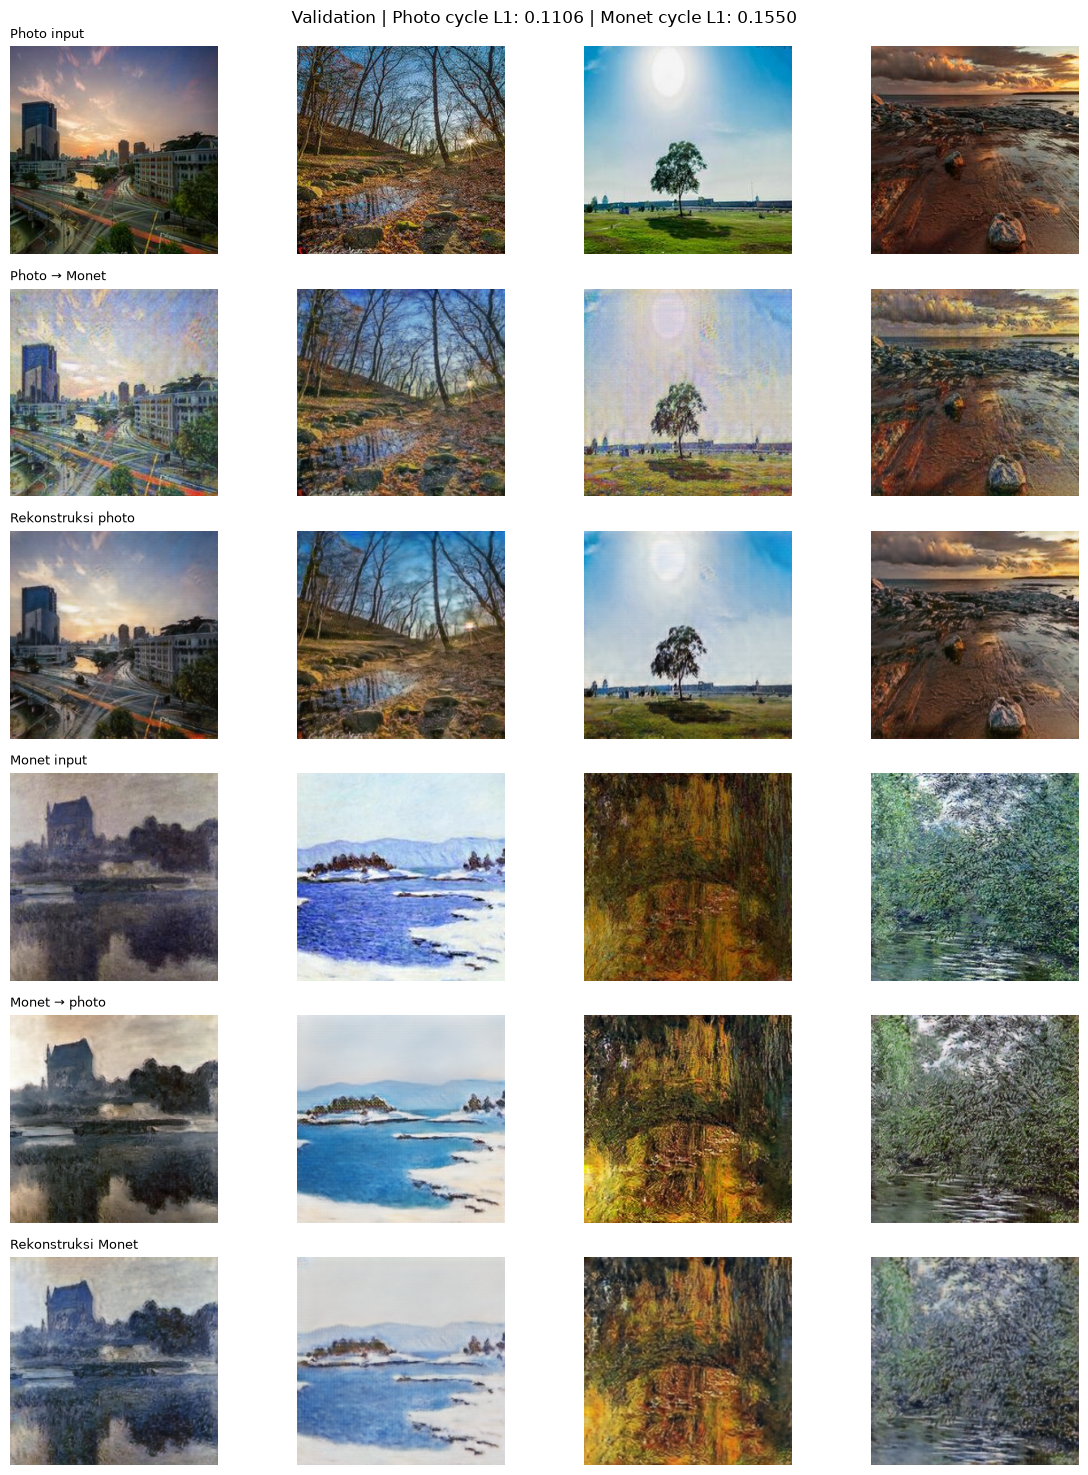

{'photo_cycle_l1': 0.11062556691467762, 'monet_cycle_l1': 0.15495029836893082}


In [9]:
validation_metrics = evaluate(n=4, save_path=SAMPLE_DIR / "validation_latest.png", show=True)
print(validation_metrics)
